# Performance Drift Examples

Data drift is the early warning. Performance drift is the confirmation.

- **Data drift** = the *inputs* changed. Detectable immediately with no labels needed (PSI, KS test).
- **Performance drift** = the model's *predictions became wrong*. Requires ground truth labels to measure (AUC, F1, Recall dropped).

In real life: you detect data drift first, then wait for labels to arrive to confirm performance dropped.

This notebook simulates both: we apply data drift to the inputs and measure the resulting performance drop.

Sections:
1. Train on baseline, evaluate on clean production (reference performance)
2. Apply increasing levels of drift, measure degradation
3. Visualise the performance drop

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score

# Load data
df = pd.read_parquet('../sample_data_from_redshift/sample.parquet')
df['topup_total_value'] = pd.to_numeric(df['topup_total_value'], errors='coerce')
df['topup_avg_value']   = pd.to_numeric(df['topup_avg_value'],   errors='coerce')

# Keep only numeric features — no preprocessing needed
FEATURES = [
    'tenure_days', 'contract_len_days', 'past_churns',
    'topup_total_value', 'topup_avg_value', 'topup_count',
    'contract_number', 'n_prev_contracts', 'gap_since_prev_expiry'
]
TARGET = 'churn'

df = df[FEATURES + [TARGET]].dropna()
print(f"Dataset: {len(df):,} rows | Churn rate: {df[TARGET].mean():.1%}")

Dataset: 98,434 rows | Churn rate: 36.3%


## 1. Train on baseline, evaluate on clean production

Split 50/50. Train on the first half. Evaluate on the second half — no drift yet.
This gives our **reference performance**.

In [2]:
split = len(df) // 2
train = df.iloc[:split].copy()
prod  = df.iloc[split:].copy()

model = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
model.fit(train[FEATURES], train[TARGET])

THRESHOLD = 0.308  # same threshold used by the production model

def score(X, y, label):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= THRESHOLD).astype(int)
    auc = roc_auc_score(y, proba)
    f1  = f1_score(y, preds)
    rec = recall_score(y, preds)
    print(f"{label:<35} AUC={auc:.3f}  F1={f1:.3f}  Recall={rec:.3f}")
    return auc, f1, rec

print(f"{'Dataset':<35} {'AUC':>6}  {'F1':>6}  {'Recall':>8}")
print("-" * 60)
score(train[FEATURES], train[TARGET], "Training (seen data)")
score(prod[FEATURES],  prod[TARGET],  "Production (no drift) <- reference")

Dataset                                AUC      F1    Recall
------------------------------------------------------------
Training (seen data)                AUC=0.776  F1=0.637  Recall=0.792
Production (no drift) <- reference  AUC=0.741  F1=0.614  Recall=0.767


(0.7407975873134296, 0.6144637512842275, 0.7674626199509038)

## 2. Apply increasing drift, measure degradation

We shift the production features at 5 intensity levels (0% → 100%).
The model is never retrained — it only knows the original patterns.
The labels stay the same so we can measure real performance.

In [3]:
def apply_drift(df, intensity):
    """Shift key features by a given intensity (0=no change, 1=full drift)."""
    d = df.copy()
    d['tenure_days']       = (d['tenure_days']       * (1 - 0.6 * intensity)).astype(int)
    d['contract_len_days'] = (d['contract_len_days'] * (1 - 0.6 * intensity)).astype(int)
    d['past_churns']       = (d['past_churns']       * (1 - 0.5 * intensity)).astype(int)
    d['topup_total_value'] = d['topup_total_value']  * (1 + 2.0 * intensity)
    return d

levels  = [0.0, 0.25, 0.5, 0.75, 1.0]
names   = ['No drift', 'Mild (25%)', 'Moderate (50%)', 'Severe (75%)', 'Extreme (100%)']
results = []

print(f"{'Drift Level':<20} {'AUC':>6}  {'F1':>6}  {'Recall':>8}")
print("-" * 45)

for intensity, name in zip(levels, names):
    drifted = apply_drift(prod, intensity)
    auc, f1, rec = score(drifted[FEATURES], prod[TARGET], name)
    results.append({'name': name, 'intensity': intensity, 'auc': auc, 'f1': f1, 'recall': rec})

Drift Level             AUC      F1    Recall
---------------------------------------------
No drift                            AUC=0.741  F1=0.614  Recall=0.767
Mild (25%)                          AUC=0.684  F1=0.522  Recall=0.517
Moderate (50%)                      AUC=0.679  F1=0.488  Recall=0.445
Severe (75%)                        AUC=0.685  F1=0.429  Recall=0.339
Extreme (100%)                      AUC=0.645  F1=0.453  Recall=0.414


## 3. Visualise the degradation

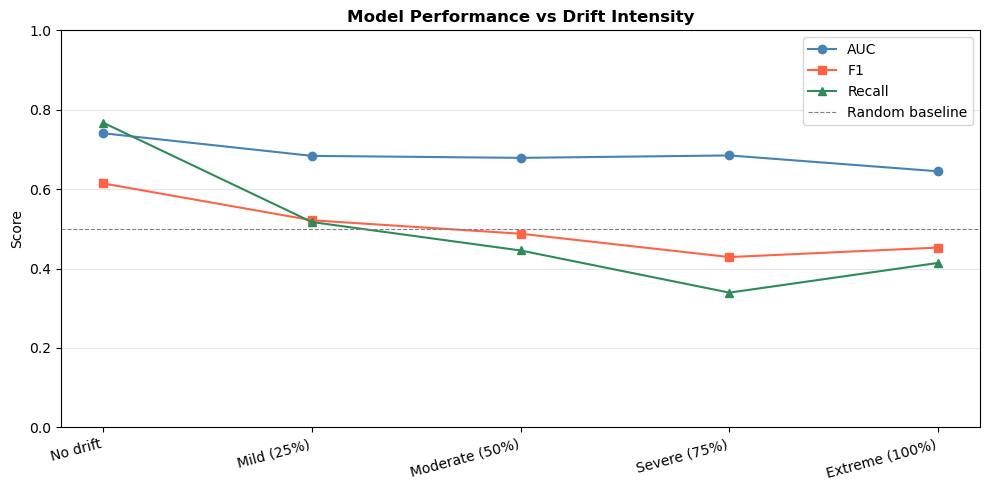

AUC drop (no drift → extreme): 0.096
F1  drop (no drift → extreme): 0.162


In [4]:
res = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res['intensity'], res['auc'],    marker='o', label='AUC',    color='steelblue')
ax.plot(res['intensity'], res['f1'],     marker='s', label='F1',     color='tomato')
ax.plot(res['intensity'], res['recall'], marker='^', label='Recall', color='seagreen')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')

ax.set_xticks(res['intensity'])
ax.set_xticklabels(res['name'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Performance vs Drift Intensity', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC drop (no drift → extreme): {res['auc'].iloc[0] - res['auc'].iloc[-1]:.3f}")
print(f"F1  drop (no drift → extreme): {res['f1'].iloc[0]  - res['f1'].iloc[-1]:.3f}")

## Key takeaway

- At **no drift**, the model performs as expected
- As drift increases, all metrics decline — the model is predicting patterns that no longer exist in the data
- The model doesn't know it's wrong — it still returns a score for every row

This is why we monitor **data drift proactively**: by the time performance degrades,
real customers have already received bad predictions.

**The fix:** retrain the model on recent data when significant drift is detected.